# Nondimensional Features

## Dimensional Analysis

When dealing with machine learning problems for physical systems the quantities we use as features and targets have *dimensionality*. 

For example consider a simple pendulum of length l $[L]$, mass m $[M]$, gravitational (acceleration) constant g $[L T^{-2}]$, where we want to learn the frequency f $[T^{-1}]$.

<img src="pendulumswing.jpg" width="320" style="display=block; margin-left:auto; margin-right:auto"/>


We could feed these features as-is to a machine learning model that might do very well on lab generated data, but would it be able to generalize to let's say a pendulum the size of a carinval ride or a pendulum on the moon?

In order to help the model we could try to incorporate some physics knowledge. The basic idea of dimensional analysis is that for any equation the dimensions must match on the left- and right hand sides.

By ansatz:

$f = \phi(l, m, g) = k l^{\alpha} m^{\beta} g^{\gamma}$

Since the dimensionalities must match we can apply these exponents to the dimensions:

$T^{-1} = k L^{\alpha} M^{\beta} (L T^{-2})^{\gamma} = k L^{\alpha + \gamma} M^{\beta} T^{-2\gamma}$

$\left\{
\begin{aligned}
L&: 0 = \alpha + \gamma  \\
M&: 0 = \beta \\
T&: -1 = -2 \gamma
\end{aligned} \right.$


This immediately yields $\gamma = \frac{1}{2}, \beta = 0, \alpha = -\frac{1}{2}.$

We have found the equation for the frequency of the simple pendulum without any force balancing, vector algebra, trigonometry etc.

$f = k \sqrt{\frac{g}{l}}$

This means that the frequency can be predicted by $\sqrt{\frac{g}{l}}$ alone, and using this as a feature we would only have to make the model learn a function $\phi(\sqrt{\frac{g}{l}})$, or in the linear regime, the constant k. This holds for all ranges of lengths and gravities.



You may have noticed the logical leap when deriving the dependence on $\sqrt{\frac{g}{l}}$ from the linear model, and claiming this also applies in the general nonlinear case, i.e. $\phi$ is *only* a funtion of $\sqrt{\frac{g}{l}}$. To really show this we need the [Buckingham $\pi$ theorem](https://ocw.mit.edu/courses/2-25-advanced-fluid-mechanics-fall-2013/c0a4521f55e9191d557c167e99e97469_MIT2_25F13_The_Buckingham.pdf).

In short this tells us that *any physical system* described as a function of variables $q_0,...q_i$ can also be described as a function of a dimensionless group of variables $\Pi_0,...\Pi_j$ where j ≤ i.

For the pendulum we only need one dimensionless variable $\Pi_0 = f\sqrt{\frac{l}{g}}.$ and its behaviour is described by some functional $F(\Pi_0) = 0$.

## Machine Learning

Let's explore the benefits of using non-dimensional features in Machine Learning.

Intuitively non-dimensional features could help models by allowing them to interpolate instead of extrapolate, and reducing the feature space so they can focus on learning the core relationships.

In the case of the pendulum, this means we could find frequencies on the moon based on earth data as long as the ratio $l/g$ stays somewhat within the training data range, and the model wouldn't have to fit the nonlinear relationship $\sqrt{\frac{\bullet}{\bullet}}$.

> An anecdote: I have successfully used dimensional analysis in practice.
> A company I worked for needed a model for an inline quality control system.
> The requirement was that it must be a linear regression model due to it running on PLCs and implemented manually by technicians.
> A few people before me attempted to solve it using polynomial regression, but there were still problematic nonlinearities, a lot of variance, and the coefficients couldn't generalize well across product types.
> I created a non-dimensional group out of the given features, observed that these actually followed a nice linear relationship where one model could describe the full width and breadth of different product types.
> In the end the model was only feasible \& accurate thanks to the non-dimensional features having this uncanny ability to generalize.
> This was a few years ago but it was implemented in production and estimated to have saved millions of \$ since.

### Airfoil Example

Let's try try it out on a dataset from NASA on airfoils in a wind tunnel experiment.

In [947]:
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
sns.set_style("ticks")
sns.color_palette("dark")
plt.rc("axes.spines", top=False, right=False)
plt.rc("figure", figsize= (12,8))

import pandas as pd
import numpy as np


In [950]:
airfoil_self_noise = fetch_ucirepo(id=291) 
data = airfoil_self_noise.data
X = data.features 
y = data.targets["scaled-sound-pressure"]

airfoil_self_noise.metadata


{'uci_id': 291,
 'name': 'Airfoil Self-Noise',
 'repository_url': 'https://archive.ics.uci.edu/dataset/291/airfoil+self+noise',
 'data_url': 'https://archive.ics.uci.edu/static/public/291/data.csv',
 'abstract': 'NASA data set, obtained from a series of aerodynamic and acoustic tests of two and three-dimensional airfoil blade sections conducted in an anechoic wind tunnel.',
 'area': 'Physics and Chemistry',
 'tasks': ['Regression'],
 'characteristics': ['Multivariate'],
 'num_instances': 1503,
 'num_features': 5,
 'feature_types': ['Real'],
 'demographics': [],
 'target_col': ['scaled-sound-pressure'],
 'index_col': None,
 'has_missing_values': 'no',
 'missing_values_symbol': None,
 'year_of_dataset_creation': 1989,
 'last_updated': 'Fri Mar 29 2024',
 'dataset_doi': '10.24432/C5VW2C',
 'creators': ['Thomas Brooks', 'D. Pope', 'Michael Marcolini'],
 'intro_paper': None,
 'additional_info': {'summary': 'The NASA data set comprises different size NACA 0012 airfoils at various wind tunnel

In [218]:
airfoil_self_noise.variables

,name,role,type,demographic,description,units,missing_values
0,frequency,Feature,Integer,None,None,Hz,no
1,attack-angle,Feature,Binary,None,None,deg,no
2,chord-length,Feature,Continuous,None,None,m,no
3,free-stream-velocity,Feature,Continuous,None,None,m/s,no
4,suction-side-displacement-thickness,Feature,Continuous,None,None,m,no
5,scaled-sound-pressure,Target,Continuous,None,None,dB,no


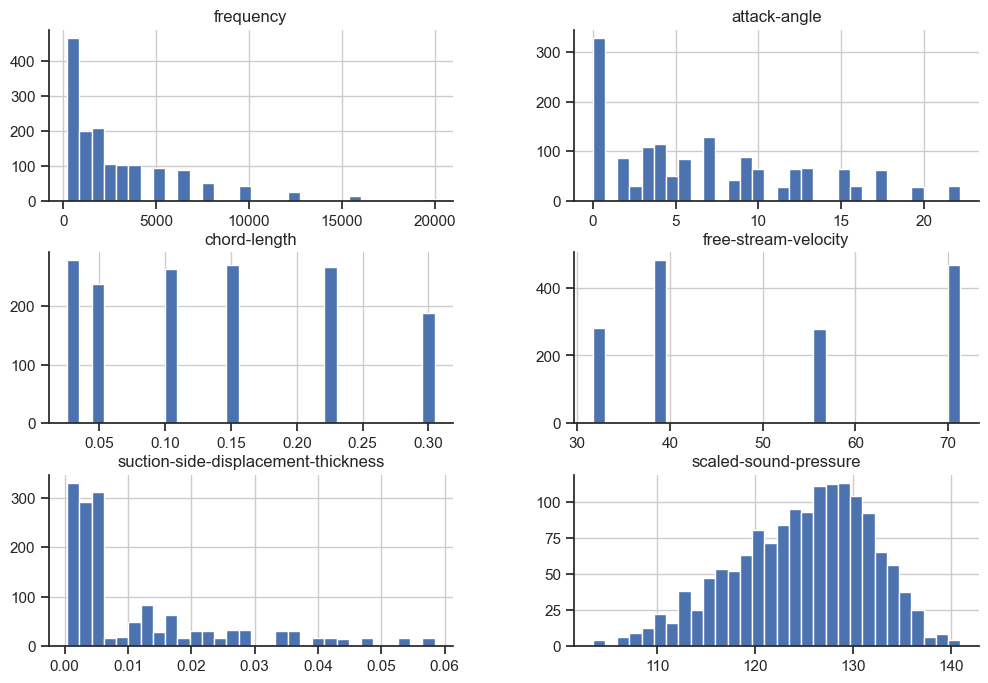

In [219]:
X.join(y).hist(bins=30);

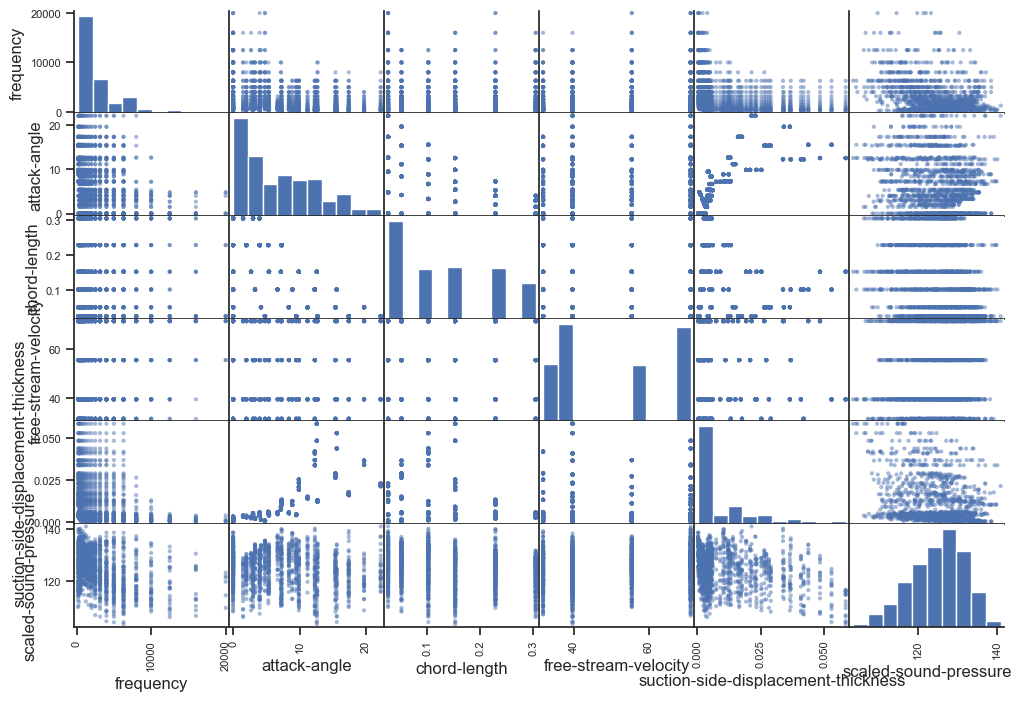

In [221]:
pd.plotting.scatter_matrix(X.join(y));

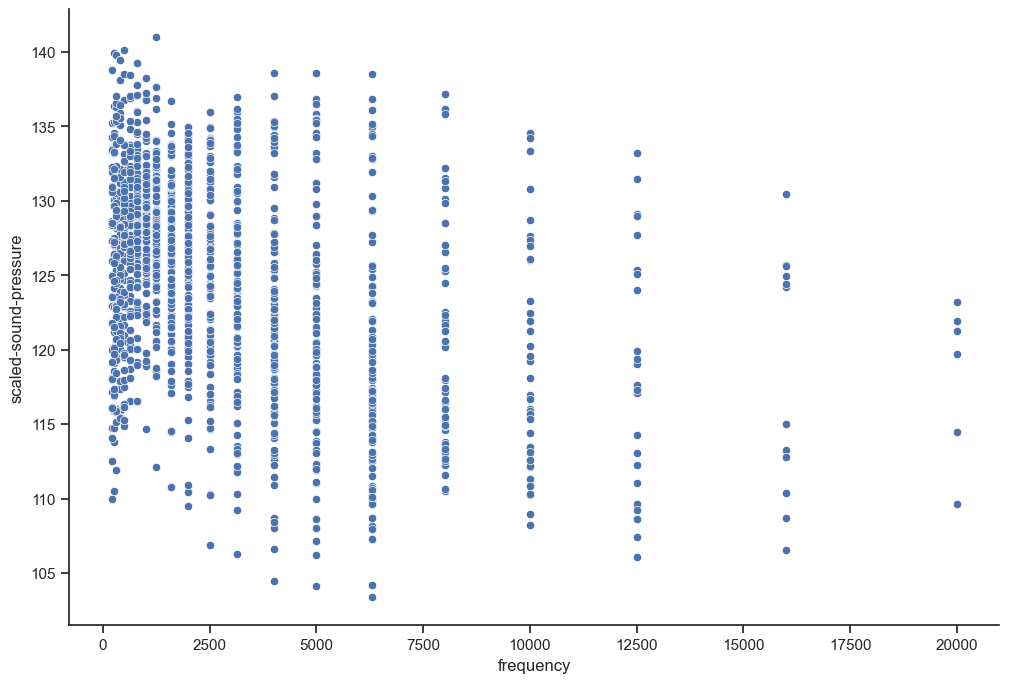

In [814]:
sns.scatterplot(x=X["frequency"], y=y);


To showcase the extrapolation capabilities of non-dimensional features, let's reserve the largest frequencies as a test set.

In [2026]:
test_inds = X["frequency"] > 2000
X_test = X.loc[test_inds,:]
y_test = y.loc[test_inds]
X_train = X.loc[~test_inds,:]
y_train = y.loc[~test_inds]
print(f"Train size: {y_train.shape[0]}, test_size: {y_test.shape[0]}")

Train size: 872, test_size: 631


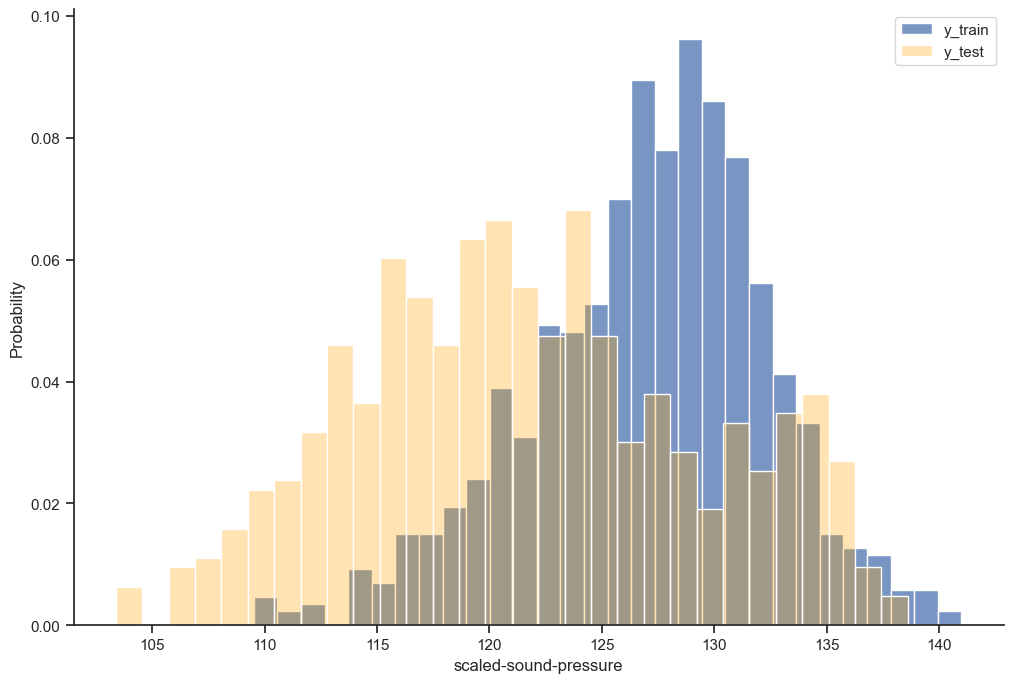

In [2027]:
sns.histplot(y_train, bins=30, stat="probability")
sns.histplot(y_test, bins=30, stat="probability", alpha= 0.3, color="orange")
plt.legend(["y_train", "y_test"])

### Feature Engineering
What are we working with here? There are 5 features and 1 target.

| Name     | Dimension      | variable |
| ------------- | ------------- | ------------- |
| frequency | $T^{-1}$ | $f$ |
| attack-angle | $1$ | $\theta$ |
| chord-length | $L$ | $l$ |
| free-stream-velocity | $L T^{-1}$ | $v$ |
| suction-side-displacement-thickness | $L$ | $d$|
| scaled-sound-pressure | $1$ | $y$ |

We are blessed with two quantities already being dimensionless, especially fortunate for the target as we will see. Scaled sound pressure measured in dB is dimensionless since it is a ratio of pressures, the raw sound pressure would have had dimensionality $[M L^{-1} T^{-2}]$ which would neccesitate introducing some auxilliary variable that contains mass, for example the constant density of air.

We can repeat the same method as before to construct a dimensionless group out of $f, l, v, d$ by assuming the following relation:

$$y = f^{\alpha} l^{\beta} v^{\gamma} d^{\delta}$$

Plug in the dimensions

$$L^0T^0 = 1 = T^{-\alpha} L^{\beta} (L T^{-1})^{\gamma} L^{\delta}$$

Match the exponents

$$L^0T^0 = L^{\beta + \gamma+ \delta} T^{-\alpha-\gamma}$$

Linear system of equations

$$\left\{
\begin{aligned}
T&: 0 = -\alpha - \gamma  \\
L&: 0 = \beta + \gamma + \delta
\end{aligned} \right. \quad \Rightarrow \quad  0 = -\alpha + \beta + \delta $$


This is indeterminate with 2 degrees of freedom. Let's choose $\alpha = 1$.


This means 

$$
\left\{
\begin{aligned}
\alpha &= 1  \\
\beta &= 1 - \delta \\
\gamma &= -1 \\ 
\end{aligned} \right.
$$

Non-dimensional groups are not unique, different choices are possible here, but we need a base that spans the exponents. We can define two non-dimensional variables corresponding to $\delta = 0, \delta=1$.



$$\Pi_0 : 
\left\{
\begin{aligned}
\alpha &= 1  \\
\beta &= 1  \\
\gamma &= -1 \\
\delta &= 0
\end{aligned} \right.
$$


$$
\Pi_1 : 
\left\{
\begin{aligned}
\alpha &= 1  \\
\beta &= 0  \\
\gamma &= -1 \\
\delta &= 1
\end{aligned} \right.
$$

> Note that $\Pi_0$, $\Pi_1$ are symmetrical of the form $\frac{fL}{v}$, this is called the Strouhal Number and is used in fluid dynamics to describe vortex shedding and related phenomena. A physicist would probably choose a dimensionless group consisting of the Strouhal number using the airfoil thickness d and some other number that involves the length l, for example the Reynolds number. But this is a machine learning article so we'll pretend we didn't see that.

In [2028]:
def nondim_trans(X, delta_basis=(0,1)):
    d_0, d_1 = delta_basis
    pi_0 = X["frequency"]**1 * X["chord-length"]**(1-d_0) * X["free-stream-velocity"]**-1 * X["suction-side-displacement-thickness"]**d_0
    pi_1 = X["frequency"]**1 * X["chord-length"]**(1-d_1) * X["free-stream-velocity"]**-1 * X["suction-side-displacement-thickness"]**d_1
    return pd.DataFrame(data=np.vstack([pi_0, pi_1]).T, columns=["pi_0", "pi_1"])

In [2029]:
X_train_trans = nondim_trans(X_train)
X_test_trans = nondim_trans(X_test)

$\Pi$ varies by several orders of magnitude, so let's work with the logarithm from now on.

In [2030]:
X_train_trans = X_train_trans.apply(np.log)
X_train_trans["attack-angle"]  = X_train["attack-angle"].values

X_test_trans = X_test_trans.apply(np.log)
X_test_trans["attack-angle"]  = X_test["attack-angle"].values

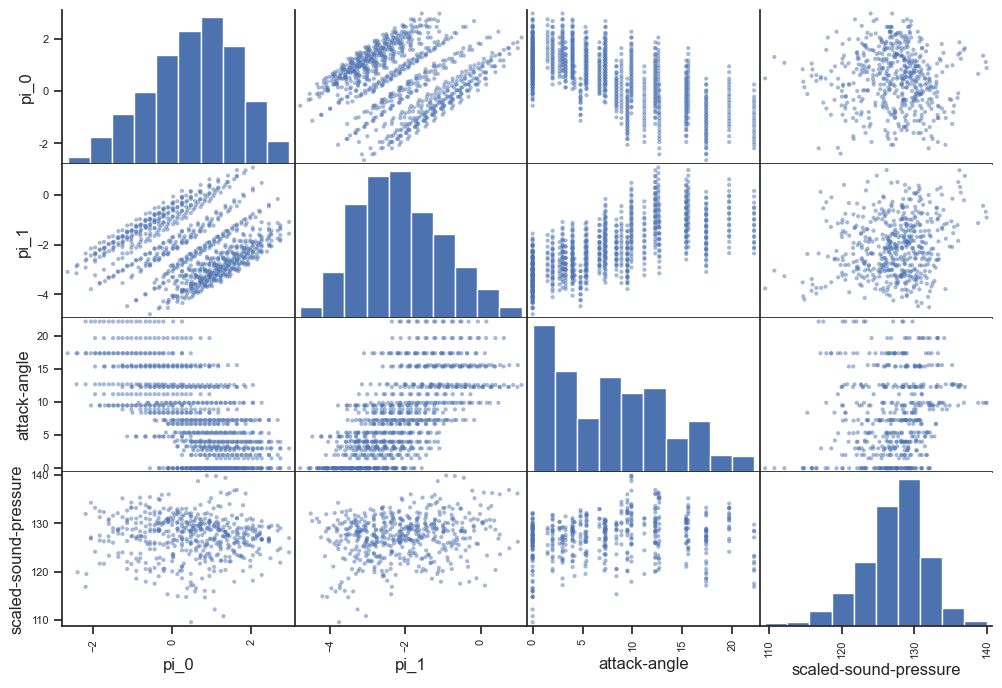

In [2031]:
pd.plotting.scatter_matrix(X_train_trans.join(y_train));

In [2032]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

In [2062]:
model_trans = RandomForestRegressor(max_depth=4, n_estimators=100)
model_orig = RandomForestRegressor(max_depth=4, n_estimators=100)

In [2063]:
model_trans.fit(X_train_trans, y_train);
model_orig.fit(X_train, y_train);

In [2064]:
yh_trans = model_trans.predict(X_test_trans)
yh_orig  = model_orig.predict(X_test)

yh_trans_tr = model_trans.predict(X_train_trans)
yh_orig_tr  = model_orig.predict(X_train)

In [2065]:
rmse_trans_test=root_mean_squared_error(yh_trans, y_test)
rmse_orig_test=root_mean_squared_error(yh_orig, y_test)
rmse_trans_train=root_mean_squared_error(yh_trans_tr, y_train)
rmse_orig_train=root_mean_squared_error(yh_orig_tr, y_train)
print(f"RMSE: train nondim {rmse_trans_train:.2f}, train orig {rmse_orig_train:.2f}, test nondim {rmse_trans_test:.2f}, test orig {rmse_orig_test:.2f}")

RMSE: train nondim 3.50, train orig 3.60, test nondim 4.70, test orig 8.46


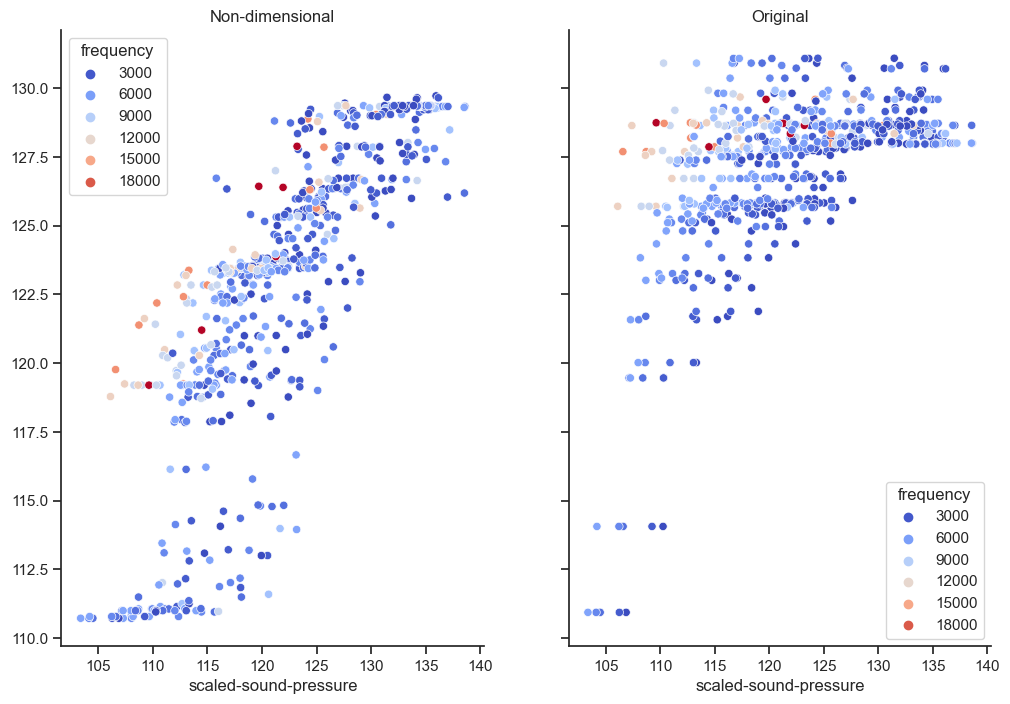

In [2069]:
fig, axes = plt.subplots(1, 2, sharex= True, sharey=True)
sns.scatterplot(x=y_test, y=yh_trans, hue = X_test["frequency"], ax=axes[0], palette = "coolwarm");
sns.scatterplot(x=y_test, y=yh_orig, hue = X_test["frequency"], ax=axes[1], palette = "coolwarm");
axes[0].set_title('Non-dimensional');
axes[1].set_title('Original');

In this case the nondimensional version seems to have learned a bit more about what happens at higher frequencies than the model based on the original features. It is also better calibrated out of sample, the original version overshoots. When testing it became clear that the original version wins in many cases when the test set isn't as extreme. The best method may be to add the nondimensional features to the originals. I hope this illustrates the point of using dimensional analysis.